<a href="https://colab.research.google.com/github/rmndrs89/advanced-time-series-prediction/blob/main/2_BaselineModel/TensorflowData.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.tensorflow.org/guide/data#decoding_image_data_and_resizing_it



In [1]:
from google.colab import drive
drive.mount("/content/drive")
import tensorflow as tf
import keras
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Mounted at /content/drive


In [2]:
from pathlib import Path
DATASET_PATH = Path("/content/drive/MyDrive/Datasets/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"
train_dataframe = pd.read_csv(DATASET_PATH / "train.csv")
test_dataframe = pd.read_csv(DATASET_PATH / "test.csv")

In [3]:
# Instantiate a Dataset from a list of files
list_ds = tf.data.Dataset.list_files(str(TRAIN_PATH/'*.npy'))

In [35]:
# Define a function to handle a single file
def parse_file(filename):
    def _load_numpy(f):
        f = f.numpy().decode("utf-8")
        with open(f, 'rb') as f:
            arr = np.load(f)
        features = arr[:, 1:4].astype(np.float32)
        labels = np.argmax(arr[:, 4:], axis=1)
        label = (np.sum(labels) > 0).astype(np.float32)
        return features, label

    features, label = tf.py_function(_load_numpy, [filename], Tout=(tf.float32, tf.float32))
    features.set_shape([1280, 3])
    label.set_shape([])
    return features, label

In [5]:
def plot_example(features, label):
    fig, ax = plt.subplots()
    ax.plot(features, lw=2)
    ax.set_title(f"Label: {label}")
    plt.show()

In [6]:
file_path = next(iter(list_ds))
features, label = parse_file(file_path)

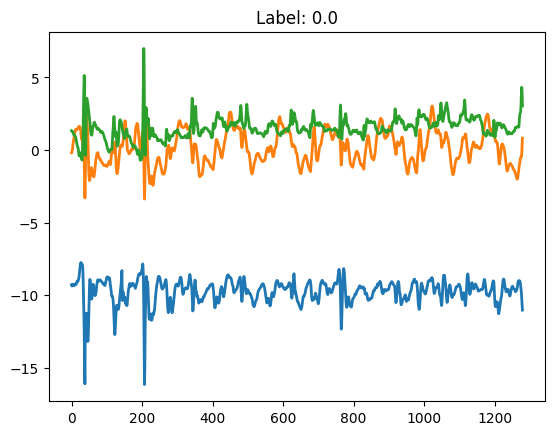

In [7]:
plot_example(features, label)

### Build dataset pipeline

In [36]:
train_ds = list_ds.map(parse_file)
NUM_TRAIN_EXAMPLES = len(train_ds)
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 100
train_ds = train_ds.shuffle(SHUFFLE_BUFFER_SIZE).batch(BATCH_SIZE).repeat()  # a shuffle placed before a repeat will show every element of one epoch before moving to the next

STEPS_PER_EPOCH = NUM_TRAIN_EXAMPLES // BATCH_SIZE
NUM_EPOCHS = 2

### Build model

#### Helper function

In [37]:
def build_model(input_shape: tuple[int, int]):
    inputs = keras.layers.Input(shape=input_shape, name="inputs")
    flatten = keras.layers.Flatten(name="flatten")(inputs)
    outputs = keras.layers.Dense(units=1, activation="sigmoid", name="outputs")(flatten)
    model = keras.Model(inputs=inputs, outputs=outputs, name="flattened_model")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [38]:
# Infer shape frmo dataset
num_time_steps, num_channels = next(iter(train_ds))[0].shape[1:]

In [ ]:
model = build_model(input_shape=(num_time_steps, num_channels))
model.summary()
history = model.fit(train_ds, steps_per_epoch=STEPS_PER_EPOCH, epochs=NUM_EPOCHS)

Model: "flattened_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 1280, 3)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 1)              │         3,841 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,841 (15.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
 76/129 ━━━━━━━━━━━━━━━━━━━━ 7:04 8s/step - accuracy: 0.5640 - loss: 1.8253